# Simulation of the scintillation quenching

In [1]:
pip install TDCRPy==2.16.16

Note: you may need to restart the kernel to use updated packages.


In [2]:
import tdcrpy as td
import matplotlib.pyplot as plt
import numpy as np

/usr/local/python/3.12.1/lib/python3.12/site-packages/tdcrpy/TDCR_model_lib.py:16: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Calculate the quenched energy from the Birks model

$dL/dx = (S * dE/dx) / (1 + kB * dE/dx + C * (dE/dx)^2)$

It include the [second order correction for biomolecular effect](https://journals.aps.org/pr/abstract/10.1103/PhysRev.87.376) parametrized with the chou parameter $C$. It is set by defaut to 0.

In [8]:
kB = 0.01  # Birks constant in cm/MeV
C = 0      # Chou constant in cm2/MeV2
ei = 1000  # initial energy in keV
ed = 1000  # deposited energy in keV
nE = 10000 # number of points of the energy linear space


eq_e=td.TDCR_model_lib.E_quench_e(ei*1e3,ed*1e3,kB,nE,kC=C)*1e-3
print(f"For electrons       => Initial energy = {ei} keV, deposited energy = {ed} keV, quenched energy = {eq_e:.5g} keV")
eq_a=td.TDCR_model_lib.E_quench_a(ei,kB*1e-3,nE)
print(f"For alpha particles => Initial energy = {ei} keV, quenched energy = {eq_a:.5g} keV")

For electrons       => Initial energy = 1000 keV, deposited energy = 1000 keV, quenched energy = 975.23 keV
For alpha particles => Initial energy = 1000 keV, quenched energy = 48.934 keV


## Correction of the reverse micelle effect

To account for the loss of energy in reverse micelles, the deposited energy ratios were evaluation by GEANT4-DNA [1]. The following diameters of reverse micelles can be entered: 0.5 nm, 1.0 nm, 2.0 nm, 3.0 nm, 4.0 nm, 5.0 nm, 6.0 nm, 7.0 nm, 8.0 nm, 10.0 nm. The default value is 2.0 nm. The aqueous fraction can take any values from 0 to 1.

See details in [Applied Radiation and Isotopes 125, 94–107](https://doi.org/10.1016/j.apradiso.2017.04.020).

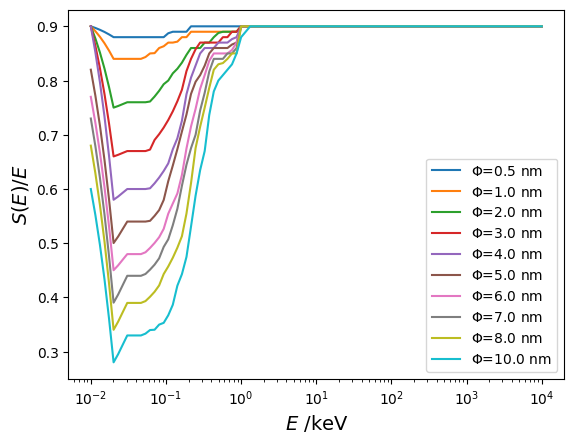

In [10]:
energy_vec = np.logspace(-2,4,100) # in keV
fAq=0.1
s05, s1, s2, s3, s4, s5, s6, s7, s8, s10 = [], [], [], [], [], [], [], [], [], []
for e in energy_vec:
    s05.append(td.TDCR_model_lib.micelleLoss(e,fAq=fAq,diam_micelle=0.5))
    s1.append(td.TDCR_model_lib.micelleLoss(e,fAq=fAq,diam_micelle=1.0))
    s2.append(td.TDCR_model_lib.micelleLoss(e,fAq=fAq,diam_micelle=2.0))
    s3.append(td.TDCR_model_lib.micelleLoss(e,fAq=fAq,diam_micelle=3.0))
    s4.append(td.TDCR_model_lib.micelleLoss(e,fAq=fAq,diam_micelle=4.0))
    s5.append(td.TDCR_model_lib.micelleLoss(e,fAq=fAq,diam_micelle=5.0))
    s6.append(td.TDCR_model_lib.micelleLoss(e,fAq=fAq,diam_micelle=6.0))
    s7.append(td.TDCR_model_lib.micelleLoss(e,fAq=fAq,diam_micelle=7.0))
    s8.append(td.TDCR_model_lib.micelleLoss(e,fAq=fAq,diam_micelle=8.0))
    s10.append(td.TDCR_model_lib.micelleLoss(e,fAq=fAq,diam_micelle=10.0))

plt.figure("Deposited energy ratio")
plt.clf()
plt.plot(energy_vec,s05,label=r"$\Phi$=0.5 nm")
plt.plot(energy_vec,s1,label=r"$\Phi$=1.0 nm")
plt.plot(energy_vec,s2,label=r"$\Phi$=2.0 nm")
plt.plot(energy_vec,s3,label=r"$\Phi$=3.0 nm")
plt.plot(energy_vec,s4,label=r"$\Phi$=4.0 nm")
plt.plot(energy_vec,s5,label=r"$\Phi$=5.0 nm")
plt.plot(energy_vec,s6,label=r"$\Phi$=6.0 nm")
plt.plot(energy_vec,s7,label=r"$\Phi$=7.0 nm")
plt.plot(energy_vec,s8,label=r"$\Phi$=8.0 nm")
plt.plot(energy_vec,s10,label=r"$\Phi$=10.0 nm")
plt.xscale('log')
plt.xlabel(r'$E$ /keV', fontsize=14)
plt.ylabel(r'$S(E)/E$', fontsize=14)
plt.legend()

## Scintillation quenching function from the Birks model

with and without the reverse micelle correction

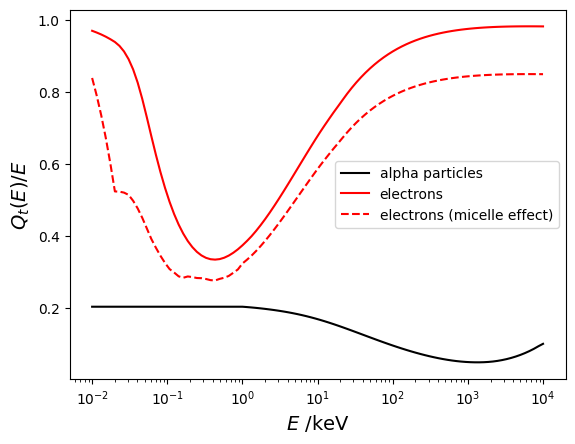

In [11]:
energy_vec = np.logspace(-2,4,100) # in keV
fAq = 0.13524 # acqueous fraction
diam_micelle = 4.0 # diameter of micelles (in nm) 

eq_a, eq_e, eq_e_m = [], [], []
for e in energy_vec:
        eq_e.append(td.TDCR_model_lib.E_quench_e(e*1e3,e*1e3,kB,nE)*1e-3)
        eq_e_m.append(td.TDCR_model_lib.E_quench_e(e*1e3,e*1e3,kB,nE)*1e-3*td.TDCR_model_lib.micelleLoss(e,fAq=fAq,diam_micelle=diam_micelle))
        eq_a.append(td.TDCR_model_lib.E_quench_a(e,kB*1e-3,nE))

plt.figure("Quenched Energy")
plt.clf()
plt.plot(energy_vec,eq_a/energy_vec,"-k",label="alpha particles")
plt.plot(energy_vec,eq_e/energy_vec,"-r",label="electrons")
plt.plot(energy_vec,eq_e_m/energy_vec,"--r",label="electrons (micelle effect)")
plt.xscale('log')
plt.xlabel(r'$E$ /keV', fontsize=14)
plt.ylabel(r'$Q_t(E)/E$', fontsize=14)
plt.legend()